In [1]:
from data_load import load_household_load, load_plant1_generation, normalize_series

In [ ]:
hhpc = load_household_load(r"C:\Users\bmani\OneDrive\Desktop\Digital-Twin-Technology-in-Micro-Grids\datasets\individual+household+electric+power+consumption\household_power_consumption.txt")

solar = load_plant1_generation(r"C:\Users\bmani\OneDrive\Desktop\Digital-Twin-Technology-in-Micro-Grids\datasets\Solar Power Generation Data\Plant_1_Generation_Data.csv")

load_pattern = normalize_series(hhpc)
solar_pattern = normalize_series(solar)

min_len = min(len(load_pattern), len(solar_pattern))

load_pattern = load_pattern.iloc[:min_len]
solar_pattern = solar_pattern.iloc[:min_len]

c:\Users\bmani\OneDrive\Desktop\Digital-Twin-Technology-in-Micro-Grids\notebooks\data_load.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
c:\Users\bmani\OneDrive\Desktop\Digital-Twin-Technology-in-Micro-Grids\notebooks\data_load.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df['Global_active_power'].resample('H').mean()
c:\Users\bmani\OneDrive\Desktop\Digital-Twin-Technology-in-Micro-Grids\notebooks\data_load.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_power = plant_power.resample('H').mean()


In [3]:
import pandapower as pp
import pandapower.networks as pn

def create_network():
    net = pn.case33bw()
    net.load['controllable'] = True
    return net

In [4]:
net = create_network()

base_loads = net.load['p_mw'].copy().values

In [5]:
pv_bus = 18

pv_index = pp.create_sgen(
    net,
    bus=pv_bus,
    p_mw=0,
    q_mvar=0,
    name="Solar_PV"
)

In [6]:
results = []

pv_capacity = 1.5  # MW (start moderate)

for t in range(48):

    # Scale load
    net.load['p_mw'] = base_loads * load_pattern.iloc[t]

    # Inject solar
    net.sgen.at[pv_index, 'p_mw'] = pv_capacity * solar_pattern.iloc[t]

    # Run power flow
    pp.runpp(net)

    vmin = net.res_bus.vm_pu.min()
    max_loading = net.res_line.loading_percent.max()

    results.append([vmin, max_loading])

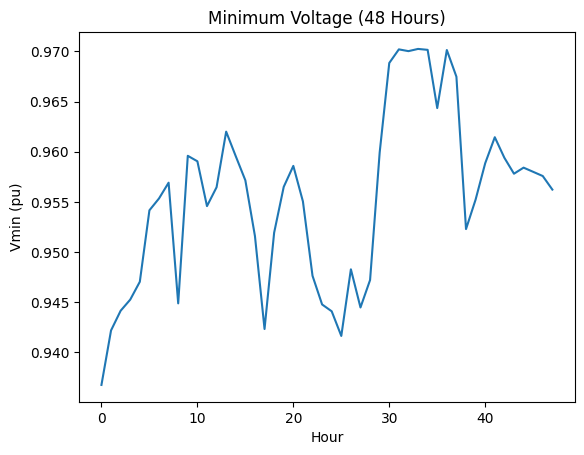

In [9]:
import matplotlib.pyplot as plt
import numpy as np

results = np.array(results)

plt.figure()
plt.plot(results[:,0])
plt.title("Minimum Voltage (48 Hours)")
plt.ylabel("Vmin (pu)")
plt.xlabel("Hour")
plt.show()